In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import ast

df = pd.read_csv(r'C:\Users\PC\Documents\Learning_PYTHON\data_jobs.csv')
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply ( lambda x: ast.literal_eval(x) if pd.notna(x) else x)


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  str           
 1   job_title              785740 non-null  str           
 2   job_location           784696 non-null  str           
 3   job_via                785733 non-null  str           
 4   job_schedule_type      773074 non-null  str           
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  str           
 7   job_posted_date        785741 non-null  datetime64[us]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  str           
 11  salary_rate            33067 non-null   str           
 12  salary_year_avg        22003 non-null   float64       


In [3]:
# Prepare the skills 

df_skills = df.copy()
df_skills = df_skills.explode('job_skills')
skills_count = df_skills.groupby(['job_skills' , 'job_title_short']).size()
skills_count = skills_count.reset_index(name="skills_count")
df_skills_count = skills_count.sort_values(by="skills_count" , ascending=False)

df_skills_count




,job_skills,job_title_short,skills_count
1480,python,Data Scientist,113711
1822,sql,Data Engineer,113130
1479,python,Data Engineer,108022
1821,sql,Data Analyst,92428
1823,sql,Data Scientist,78982
...,...,...,...
2173,webex,Senior Data Scientist,1
293,codecommit,Business Analyst,1
2233,xamarin,Machine Learning Engineer,1
1087,mlr,Machine Learning Engineer,1


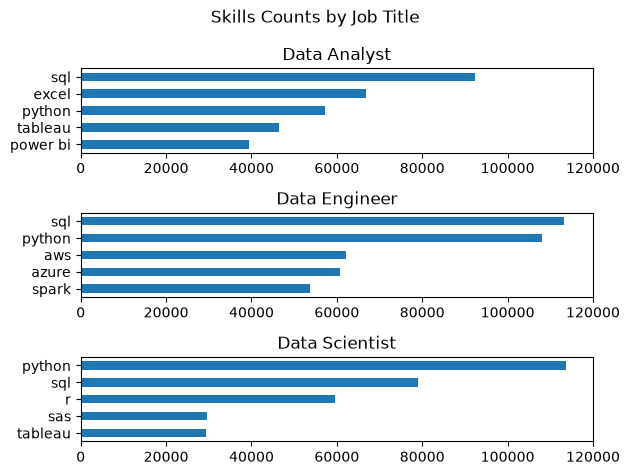

In [17]:
job_titles = ['Data Analyst' , 'Data Engineer' , 'Data Scientist']

fig , ax = plt.subplots(3,1)

for i,job_title in enumerate(job_titles) : 
    df_plot = df_skills_count[df_skills_count['job_title_short']==job_title].head()
    df_plot.plot(kind='barh' , x='job_skills' , y='skills_count' , ax=ax[i])
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].invert_yaxis()
    ax[i].set_xlim(0 , 120000)
    ax[i].legend().set_visible(False)

fig.suptitle("Skills Counts by Job Title")
fig.tight_layout()
